In [1]:
from modules.dataclass import TSP

## 1. データ入力

In [2]:
tsp = TSP(file_name='burma14.tsp')
tsp.generate()

In [3]:
problem = tsp.problem
nodes = tsp.node
tsp.describe()

problem: Problem(file_name='burma14.tsp', edge_weight_type='GEO', dimension=14, correct_answer=[0, 9, 8, 10, 7, 12, 6, 11, 5, 4, 3, 2, 13, 1])
node: [Node(id=0, x_coord=16.47, y_coord=96.1), Node(id=1, x_coord=16.47, y_coord=94.44), Node(id=2, x_coord=20.09, y_coord=92.54), Node(id=3, x_coord=22.39, y_coord=93.37), Node(id=4, x_coord=25.23, y_coord=97.24), Node(id=5, x_coord=22.0, y_coord=96.05), Node(id=6, x_coord=20.47, y_coord=97.02), Node(id=7, x_coord=17.2, y_coord=96.29), Node(id=8, x_coord=16.3, y_coord=97.38), Node(id=9, x_coord=14.05, y_coord=98.12), Node(id=10, x_coord=16.53, y_coord=97.38), Node(id=11, x_coord=21.52, y_coord=95.59), Node(id=12, x_coord=19.41, y_coord=97.13), Node(id=13, x_coord=20.09, y_coord=94.55)]


## 2.前処理

In [4]:
from modules.pre_processing import Area

In [5]:
area = Area(problem=problem, nodes=nodes)
dist_matrix = area.get_dist_matrix()
dist_matrix

{(0, 1): 153,
 (0, 2): 510,
 (0, 3): 706,
 (0, 4): 966,
 (0, 5): 581,
 (0, 6): 455,
 (0, 7): 70,
 (0, 8): 160,
 (0, 9): 372,
 (0, 10): 157,
 (0, 11): 567,
 (0, 12): 342,
 (0, 13): 398,
 (1, 0): 153,
 (1, 2): 422,
 (1, 3): 664,
 (1, 4): 997,
 (1, 5): 598,
 (1, 6): 507,
 (1, 7): 197,
 (1, 8): 311,
 (1, 9): 479,
 (1, 10): 310,
 (1, 11): 581,
 (1, 12): 417,
 (1, 13): 376,
 (2, 0): 510,
 (2, 1): 422,
 (2, 3): 289,
 (2, 4): 744,
 (2, 5): 390,
 (2, 6): 437,
 (2, 7): 491,
 (2, 8): 645,
 (2, 9): 880,
 (2, 10): 618,
 (2, 11): 374,
 (2, 12): 455,
 (2, 13): 211,
 (3, 0): 706,
 (3, 1): 664,
 (3, 2): 289,
 (3, 4): 491,
 (3, 5): 265,
 (3, 6): 410,
 (3, 7): 664,
 (3, 8): 804,
 (3, 9): 1070,
 (3, 10): 768,
 (3, 11): 259,
 (3, 12): 499,
 (3, 13): 310,
 (4, 0): 966,
 (4, 1): 997,
 (4, 2): 744,
 (4, 3): 491,
 (4, 5): 400,
 (4, 6): 514,
 (4, 7): 902,
 (4, 8): 990,
 (4, 9): 1261,
 (4, 10): 947,
 (4, 11): 418,
 (4, 12): 635,
 (4, 13): 636,
 (5, 0): 581,
 (5, 1): 598,
 (5, 2): 390,
 (5, 3): 265,
 (5, 4): 400,

## 3. 最適化

In [6]:
from modules.model_route import ModelRoute
model_route = ModelRoute(problem=problem, nodes=nodes, dist_matrix=dist_matrix)
model_route.to_optimize()
route = model_route.route
route

array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]], dtype=int8)

## 4. 後処理

In [7]:
from modules.post_proceesing import OptimizeRoute
optimize_route = OptimizeRoute(route=route)
optimize_route.add_record()
optimize_route.describe()
records = optimize_route.record

record: [OptimizeRouteRecord(city=0, order=0), OptimizeRouteRecord(city=1, order=1), OptimizeRouteRecord(city=2, order=3), OptimizeRouteRecord(city=3, order=11), OptimizeRouteRecord(city=4, order=13), OptimizeRouteRecord(city=5, order=12), OptimizeRouteRecord(city=6, order=8), OptimizeRouteRecord(city=7, order=5), OptimizeRouteRecord(city=8, order=2), OptimizeRouteRecord(city=9, order=10), OptimizeRouteRecord(city=10, order=4), OptimizeRouteRecord(city=11, order=9), OptimizeRouteRecord(city=12, order=6), OptimizeRouteRecord(city=13, order=7)]


## 5. 可視化

In [8]:
from modules.post_proceesing import Visualize
visualize = Visualize(problem=problem,nodes=nodes,record=records, dist_matrix=dist_matrix)

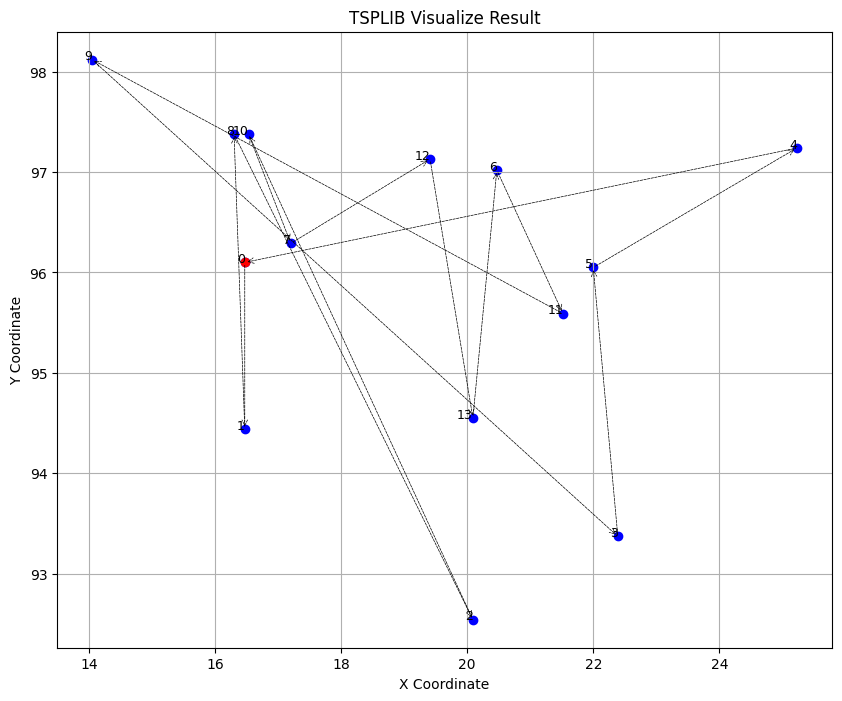

0 -> 1: 153
1 -> 8: 311
8 -> 2: 645
2 -> 10: 618
10 -> 7: 133
7 -> 12: 273
12 -> 13: 247
13 -> 6: 232
6 -> 11: 163
11 -> 9: 898
9 -> 3: 1070
3 -> 5: 265
5 -> 4: 400
4 -> 0: 966
obj value = 6374


In [9]:
# 実測値
visualize.plot_route()
visualize.to_objective_value()

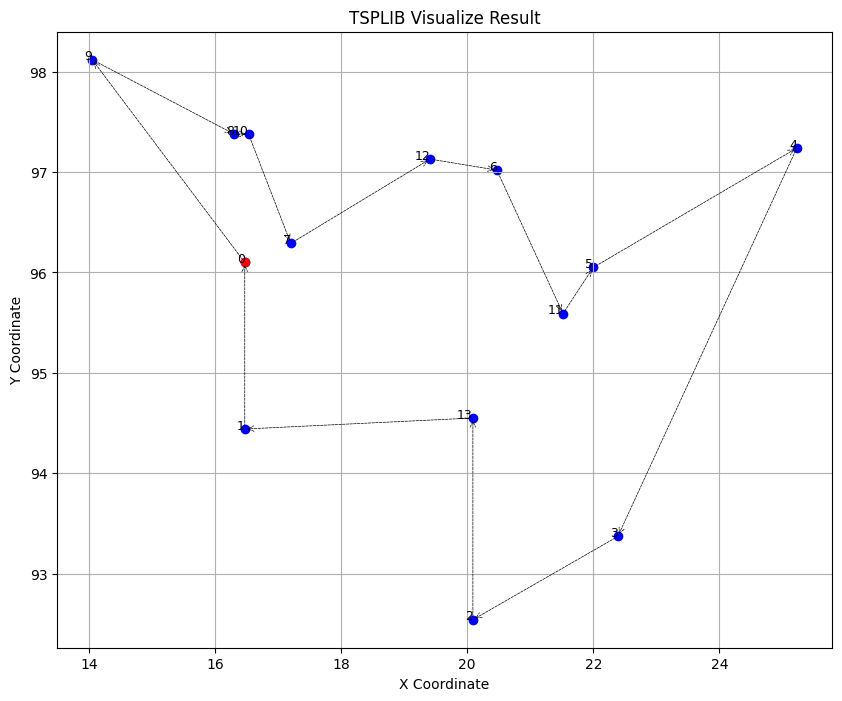

0 -> 9: 372
9 -> 8: 276
8 -> 10: 43
10 -> 7: 133
7 -> 12: 273
12 -> 6: 124
6 -> 11: 163
11 -> 5: 19
5 -> 4: 400
4 -> 3: 491
3 -> 2: 289
2 -> 13: 211
13 -> 1: 376
1 -> 0: 153
obj value = 3323


In [10]:
# 正解
visualize.plot_route(correct_ans_flg=True)
visualize.to_objective_value(correct_ans_flg=True)